# Verify method with the year 2000

Compare VizHub data for COPD ozone-related mortality in the year 2000 to those calculated using this worklow

In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from utils.mortality_utils import att_frac
from utils.mortality_utils import mortality
import config
from utils.utils import require_dir, create_global_country_map
import pathlib
from utils.utils import land_filter, autosize_figure, standardise_latlon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

In [4]:
# === Path config ===
BMR_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "BMR")
POP_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "SSP_pop" / "SSP2")
MASK_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "BMR" / "masks" / "country")
O3_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "O3_obs")
TMREL_DIR = require_dir(pathlib.Path(config.SCRATCH_ROOT) / "TMREL")
BETA_DIR = require_dir(pathlib.Path(config.SCRATCH_ROOT) / "beta_ozone")
BMR_SCRATCH_DIR = require_dir(pathlib.Path(config.SCRATCH_ROOT) / "BMR_ozone")

In [3]:
# For file names
GBD_version = "GBD23"

In [4]:
# === Load data ===
bmr_file = f"{GBD_version}_BMR_Global_Country_Map_COPD_1990-2009.nc"
bmr_path = os.path.join(BMR_DIR, bmr_file)
BMR = xr.open_dataarray(bmr_path)

pop_file = "ssp2_coarse_grid_annual_2000-2100.nc"
pop_path = os.path.join(POP_DIR, pop_file)
population = xr.open_dataarray(pop_path)
# Calculate average across the "baseline" period
pop_2000 = population.sel(year=slice("1990", "2009")).mean("year")

o3_file = "Delang_BME_OSDMA8_1990_2017.nc"
o3_path = os.path.join(O3_DIR, o3_file)
o3 = xr.open_dataset(o3_path)["ozone"]
# Calculate average across the "baseline" period
o3_2000 = o3.sel(year=slice("1990", "2009")).mean("year")
o3_2000 = standardise_latlon(o3_2000)

in_file = "GBD_Country_Masks_0.10.nc"
in_path = os.path.join(MASK_DIR, in_file)
country_mask = xr.open_dataarray(in_path)

In [5]:
# Adjust indices to match (with small tolerance)
# e.g., max 1e-7 km distance
o3_2000 = o3_2000.reindex_like(BMR, method="nearest", tolerance=1e-9,
                               fill_value=0)
pop_2000 = pop_2000.reindex_like(BMR, method="nearest", tolerance=1e-9)

# Flag if any nans present (i.e. reindex was out of tolerance distance)
assert not pop_2000.isnull().any()

## Gridpoint and country level mortality

The relative risk (RR) for a 10ppb increase in OSDMA8 is 1.074 [95% CI 1.012 - 1.137] and

$RR(x, y) = e^{\beta \, (OSDMA8(x, y) - TMREL)}$

In [6]:
# === Calculate beta for RR GBD 2021 ===

# Relative risk for 10ppb increase in OSDMA8, GBD 2021
RR_10ppb = 1.074  # [95% CI 1.014 – 1.137]
# equation is: RR = e^(beta*(x-TMREL)) where RR_10ppb = e^(10beta)
beta = np.log(RR_10ppb)/10

# TMREL from GBD 2021
TMREL = 32.4  # [95% CI 29.1 – 35.7]

AF = att_frac(o3_2000, TMREL, beta)
M = mortality(AF, BMR, pop_2000)

In [7]:
countries = []
# Loop over countries and sum the mortality for each country
for i in range(len(country_mask.country)):
    #print(f"Country number {i}")
    mask = country_mask.isel(country=i)
    # Sum mortality of country (based on central estimates)
    M_country = (xr.where(
        mask == 1,
        M,
        np.nan
    )).sum(dim=("lat", "lon"))
    countries.append(M_country.drop_vars("country", errors='ignore'))

mortality_country = xr.concat(
    countries,
    dim=xr.DataArray(country_mask["country"], dims="country", name="country")
)

Plot for comparison

Text(0.5, 1.0, 'COPD mortality for 1990-2009')

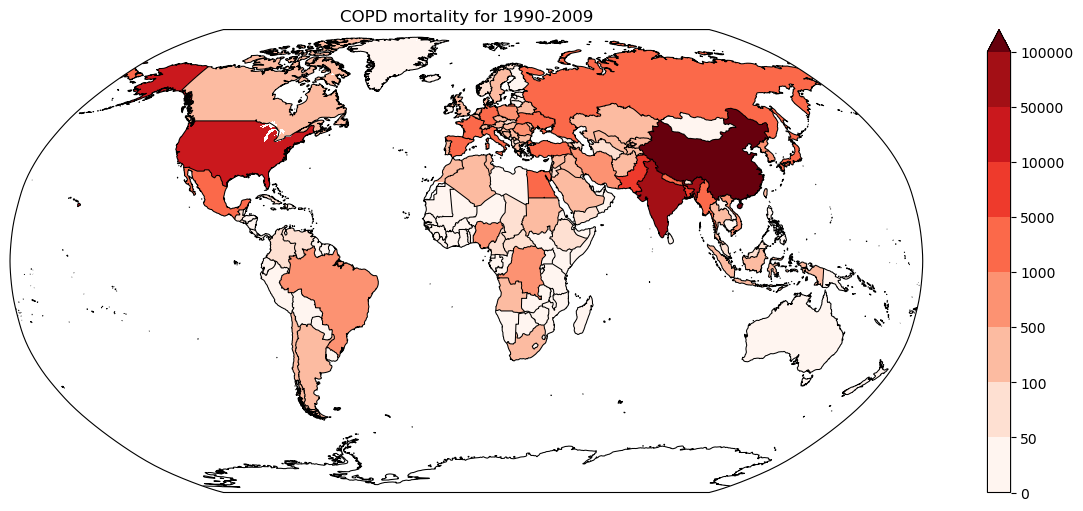

In [8]:
fig = plt.figure(figsize=autosize_figure(1, 1, xscale_factor=2))
gs = GridSpec(1, 1)  # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('Reds')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')


# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
land_filter(create_global_country_map(mortality_country, MASK_DIR)).plot(transform=ccrs.PlateCarree(), cmap=col_map, levels=[0, 50, 100, 500, 1000, 5000, 10000, 50000, 100000])
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("COPD mortality for 1990-2009")

## Global mortality

In [9]:
# === Calculate the scalar distributions ===
n_samples = 300

# TMREL from GBD23 (uniform distribution)
tmrel_file = f"{GBD_version}_TMREL_{n_samples}_samples_ozone.nc"
tmrel_path = os.path.join(TMREL_DIR, tmrel_file)
tmrel_da = xr.open_dataarray(tmrel_path)

# Beta from RR per 10ppb (normal distribution)
beta_file = f"{GBD_version}_beta_{n_samples}_samples_ozone.nc"
beta_path = os.path.join(BETA_DIR, beta_file)
beta_da = xr.open_dataarray(beta_path)

# Load BMR for each grid point (normal distribution)
bmr_file = f"{GBD_version}_BMR_Country_Mask_COPD_{n_samples}_samples_1990-2009.nc"
bmr_path = os.path.join(BMR_SCRATCH_DIR, bmr_file)
BMR = xr.open_dataarray(bmr_path)

In [10]:
AF = att_frac(o3_2000, tmrel_da, beta_da)
M = mortality(AF, BMR, pop_2000)
global_M = M.sum(dim=("lat", "lon"))

del AF, tmrel_da, beta_da

In [18]:
mean = global_M.mean("samples").values.round(-3)
lower = global_M.quantile(0.025, "samples").values.round(-3)
upper = global_M.quantile(0.975, "samples").values.round(-3)
print(f"Global mortality is {mean} [{lower}, {upper}]")

Global mortality is 257000.0 [68000.0, 466000.0]


# Vizhub data

In [6]:
GBD_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "GBD23")
gbd_2000_file = "IHME-GBD_2023_DATA-f8520351-1_newlabels.nc"
path = os.path.join(GBD_DIR, gbd_2000_file)
gbd_2000 = xr.open_dataset(path)

Plot for comparison

Text(0.5, 1.0, 'COPD mortality for 2000')

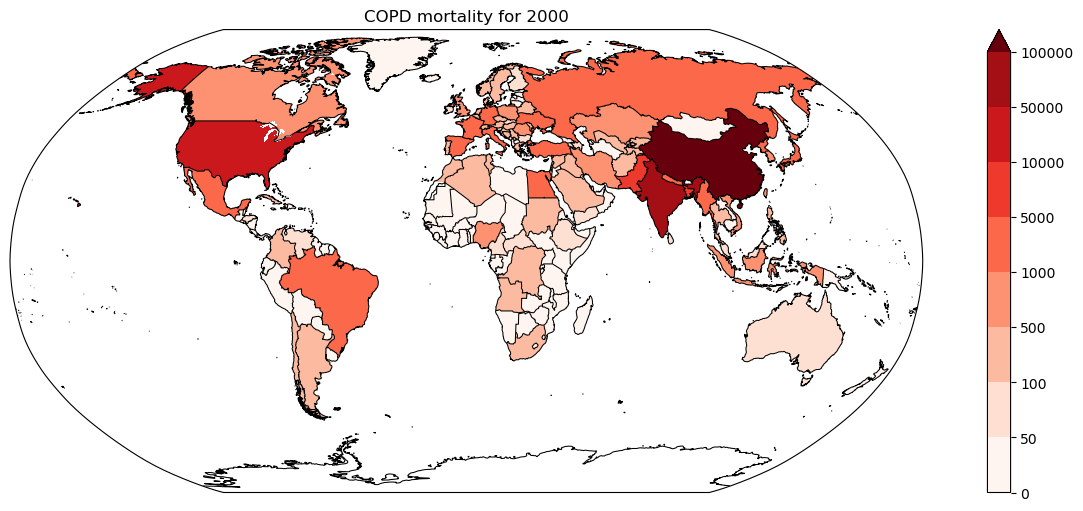

In [7]:
gbd_mean = gbd_2000["val"]

fig = plt.figure(figsize=autosize_figure(1, 1, xscale_factor=2))
gs = GridSpec(1, 1)  # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('Reds')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')


# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
land_filter(create_global_country_map(gbd_mean, MASK_DIR)).plot(transform=ccrs.PlateCarree(), cmap=col_map, levels=[0, 50, 100, 500, 1000, 5000, 10000, 50000, 100000])
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("COPD mortality for 2000")

## Global mortality - Vizhub

In [13]:
mean = np.round(261270.69, -3)
upper = np.round(461153.75, -3)
lower = np.round(62656.06, -3)
print(f"Global mortality is {mean} [{lower}, {upper}]")

Global mortality is 261000.0 [63000.0, 461000.0]
